# Задание 1.  A/B–тестирование

In [1]:
import pandas as pd 
import numpy as np
import scipy.stats as st
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from urllib.parse import urlencode
import requests
from io import StringIO

Одной из основных задач аналитика в нашей команде является корректное проведение экспериментов. Для этого мы применяем метод A/B–тестирования. В ходе тестирования одной гипотезы целевой группе была предложена новая механика оплаты услуг на сайте, у контрольной группы оставалась базовая механика. В качестве задания вам необходимо проанализировать итоги эксперимента и сделать вывод, стоит ли запускать новую механику оплаты на всех пользователей.

1. **groups** – файл с информацией о принадлежности пользователя к контрольной или экспериментальной группе (А – контроль, B – целевая группа)
2. **groups_add** – дополнительный файл с пользователями, который вам прислали спустя 2 дня после передачи данных
3. **active_studs** – файл с информацией о пользователях, которые зашли на платформу в дни проведения эксперимента. 
4. **checks** – файл с информацией об оплатах пользователей в дни проведения эксперимента. 

In [2]:
def read_csv(url, sep=','):
    key = url
    api_key = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key='+key
    response = requests.get(api_key)
    download_url = response.json()['href']
    df = pd.read_csv(download_url, sep = sep)
    return df

In [3]:
groups = read_csv('https://disk.yandex.ru/d/UhyYx41rTt3clQ', sep = ';')
group_add = read_csv('https://disk.yandex.ru/d/5Kxrz02m3IBUwQ')
active_studs = read_csv('https://disk.yandex.ru/d/Tbs44Bm6H_FwFQ')
checks = read_csv('https://disk.yandex.ru/d/pH1q-VqcxXjsVA', sep=';')

Проведем исследование данных. Какие типы данных, количество строк и столбцов, есть ли пропущенные значения.

In [4]:
groups.head()

,id,grp
0,1489,B
1,1627,A
2,1768,B
3,1783,B
4,1794,A


In [5]:
groups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74484 entries, 0 to 74483
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74484 non-null  int64 
 1   grp     74484 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [6]:
group_add.head()

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B
3,5698872,B
4,5699067,B


In [7]:
group_add.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      92 non-null     int64 
 1   grp     92 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


In [8]:
active_studs.head()

,student_id
0,581585
1,5723133
2,3276743
3,4238589
4,4475369


In [9]:
active_studs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  8341 non-null   int64
dtypes: int64(1)
memory usage: 65.3 KB


In [10]:
checks.head()

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0
3,26280,690.0
4,100300,990.0


In [11]:
checks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  541 non-null    int64  
 1   rev         541 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.6 KB


In [12]:
#Дополняем таблицу с пользователями дополнительными данными, которые прислали позже
total_group = pd.concat([groups, group_add])

In [13]:
total_group.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74576 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74576 non-null  int64 
 1   grp     74576 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.7+ MB


In [14]:
#Оставляю только тех пользователей, которые были активны в дни проведения эксперимента.
#Удаляю повтоярющейся столбец
active_groups = pd.merge(left=active_studs, right=total_group, left_on='student_id', right_on='id', how='left')
del active_groups['id']

In [15]:
active_groups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  8341 non-null   int64 
 1   grp         8341 non-null   object
dtypes: int64(1), object(1)
memory usage: 130.5+ KB


In [16]:
#Добавляю информацию о платящих пользователях
pay_active_groups = pd.merge(left = active_groups, right=checks, on='student_id', how = 'left').fillna(0)

In [17]:
#Добавляю колонку с платящими и не платящими пользователями
pay_active_groups['pay_users'] = pay_active_groups.rev.apply(lambda x: 0 if x == 0 else 1)

In [18]:
#Считаем количество платящих пользователей, попавших в эксперимент.
pay_active_groups.pay_users.sum()

392

In [19]:
#Считаем количество платящих пользователей в дни проведения эксперимента. 
checks.student_id.nunique()

541

Есть пользователи, которые оплатили услуги в дни проведения эксперимента, **но в сам эксперимент не попали**.

In [20]:
print(f"Количество пользователей, не попавших в эксперимент:\
 {checks.student_id.nunique() - pay_active_groups.pay_users.sum()}")

Количество пользователей, не попавших в эксперимент: 149


1. На какие метрики вы смотрите в ходе анализа и почему?
2. Имеются ли различия в показателях и с чем они могут быть связаны?
3. Являются ли эти различия статистически значимыми?
4. Стоит ли запускать новую механику на всех пользователей?

1. Для чистоты проведенного эксперимента нужно проанализировать две ключевые метрики: **конверсию в оплату** и **среднюю выручку на одного пользователя (ARPU)** Выбор данных метрик обоснован представленными данными: тестовая и контрольная группы, информация о пользователях которые платили и сколько они потратили. Данные метрики позволяют выявить эффективность новвоведений в продукт, в том числе отследить один из важнейших этапов взаимодействия пользователя с продуктом, а именно оплату услуг. 

In [21]:
pay_active_groups.tail()

,student_id,grp,rev,pay_users
8336,1794344,B,0.0,0
8337,296883,B,0.0,0
8338,3598448,B,0.0,0
8339,3610547,B,290.0,1
8340,205705,B,0.0,0


In [22]:
#Проверяем данные на аномалии. Есть ли пользователи, которые оплатили, но не активные
pay_active_groups.query('pay_users == 1 & rev == 0')

,student_id,grp,rev,pay_users


In [23]:
#Формируем таблицу с количеством пользователей, суммой выручки и количеством платящих клиентов по группам 
metrics = pay_active_groups.groupby('grp', as_index=False) \
    .agg({'student_id':'count', 'rev':'sum', 'pay_users':'sum'})

In [24]:
#Высчитывем метрики ARPU и CR в оплату
metrics['ARPU'] = metrics.rev / metrics.student_id
metrics['CR_pay'] = (metrics.pay_users/metrics.student_id)*100

In [25]:
metrics

,grp,student_id,rev,pay_users,ARPU,CR_pay
0,A,1538,72820.0000,78,47.347204,5.071521
1,B,6803,394974.0035,314,58.058798,4.615611


2. Из таблицы видно, что значение **ARPU** в целевой группе **увеличилось** по сравнению с контрольной, а значение **конверсии в оплату наоборот незначительно уменьшилось**. Необходимо проверить результаты на статистическую значимость

Для метрики конверсии в оплату использую **критерий Хи-квадрат**, так как в частном случае его можно использовать для анализа конверсий. 

Сформулируем гипотезы:  
**H0** - значение конверсии в оплату в контрольной и тестовой группах не отличается.  
**H1** - значение конвресии в оплату в контрольной и тестовой группах отличается.

In [26]:
#Составляю таблицу сопряженности для последующего проведения теста.
chi_test = pd.crosstab(pay_active_groups.grp, pay_active_groups.pay_users)

In [27]:
chi_test

pay_users,0,1
grp,,
A,1460,78
B,6489,314


In [28]:
#Провожу тест, используя критерий Хи-квадрат и библотеку scipy
stat, p, dof, expected = st.chi2_contingency(chi_test)
print(f"Значение статистики: {stat}.")
print(f"Уровень значимости (p-value): {p}.")
print(f"Степени свободы: {dof}.")
print(f"Ожидаемые значения: {expected}")

Значение статистики: 0.48480826522557896.
Уровень значимости (p-value): 0.48625240457231045.
Степени свободы: 1.
Ожидаемые значения: [[1465.71897854   72.28102146]
 [6483.28102146  319.71897854]]


Уровень значимости **(p-value) больше 0.05**, что не позволяет отвергнуть нулевую гипотезу об отсутствии различий значений двух групп. Статистическая значимость - 0.49. Вероятно, что различия между группами случайны. **То есть конверсия в платящего пользователя не изменилась**.

Перед проверкой метрики ARPU необходимо выдвинуть гипотезы и проверить выборки на равенство дисперсий и нормальность.  
**H0** - значение ARPU в контрольной и тестовой группах не отличается.  
**H1** - значение ARPU в контрольной и тестовой группах отличается.

In [29]:
#Проверяем нормальность данных
pg.normality(data = pay_active_groups, dv = 'rev', group = 'grp', method ='normaltest')

,W,pval,normal
grp,,,
A,2240.595797,0.0,False
B,7797.399212,0.0,False


<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

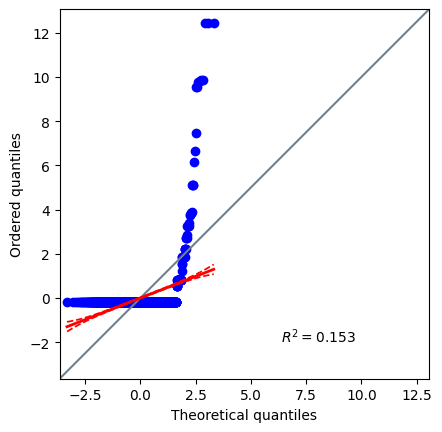

In [30]:
pg.qqplot(pay_active_groups.query('grp == "A"').rev) 

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

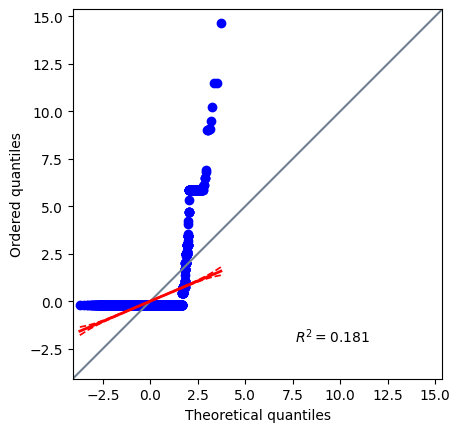

In [31]:
pg.qqplot(pay_active_groups.query('grp == "B"').rev) 

In [32]:
#Проверяем равенство дисперсий
pg.homoscedasticity(data = pay_active_groups, dv = 'rev', group = 'grp')

,W,pval,equal_var
levene,1.501461,0.220481,True


Данные характеризуются ненормальностью, большой выборкой, а также равенством дисперсий. Целесообразно использовать **T-тест Стьюдента**.

In [33]:
#Формируем отдельные переменные с данными контрольной и тестовой групп
control = pay_active_groups.query('grp == "A"').rev.values
test = pay_active_groups.query('grp == "B"').rev.values

In [34]:
#Проводим Т-тест Стьюдента.
pg.ttest(control, test, correction=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-1.286374,2416.748043,two-sided,0.198436,"[-27.04, 5.62]",0.034597,0.073,0.231965


Результаты теста показали, что нет оснований отвергать нулевую гипотезу о равенстве значений ARPU в двух группах. **Средняя выручка на одного пользователя не изменилась**.

3. Таким образом, у нас нет оснований полагать, что **конверсия в оплату**, а также **средний доход на одного пользователя** в тестовой и контрольной группах различны. В обоих случаях **статистически значимых результатов не обнаружено**.

4. Новую механику оплаты услуг на сайте применять пока не следует. Необходимы либо дальнейшие тесты, либо изменения в самой механике. Кроме того, необходимо посмотреть динамику метрик во времени, для чего понадобяться дополнительные данные. 

# Задание 2. SQL

## Задание 2.1. Очень усердные ученики

Образовательные курсы состоят из различных уроков, каждый из которых состоит из нескольких маленьких заданий. Каждое такое маленькое задание называется "горошиной". Назовём очень усердным учеником того пользователя, который хотя бы раз за текущий месяц правильно решил 20 горошин.

Необходимо написать оптимальный запрос, который даст информацию о количестве очень усердных студентов.NB! Под усердным студентом мы понимаем студента, который правильно решил 20 задач за текущий месяц.

```
SELECT count(*) as diligent_stud  
  FROM (SELECT st_id,  
               correct,  
               count(*) as cnt  
          FROM peas  
         WHERE correct is True  
         GROUP BY st_id, correct  
        HAVING count(*) >= 20  
         ORDER BY cnt) as foo  
         ```

## Задание 2.2. Оптимизация воронки

Образовательная платформа предлагает пройти студентам курсы по модели trial: студент может решить бесплатно лишь 30 горошин в день. Для неограниченного количества заданий в определенной дисциплине студенту необходимо приобрести полный доступ. Команда провела эксперимент, где был протестирован новый экран оплаты.

Необходимо в одном запросе выгрузить следующую информацию о группах пользователей: 
1. ARPU 
2. ARPAU 
3. CR в покупку 
4. СR активного пользователя в покупку  

CR пользователя из активности по математике (subject = ’math’) в покупку курса по математике
ARPU считается относительно всех пользователей, попавших в группы.

Активным считается пользователь, за все время решивший больше 10 задач правильно в любых дисциплинах.

Активным по математике считается пользователь, за все время решивший 2 или больше задач правильно по математике.

```
 WITH active_users AS (SELECT foo.st_id
                         FROM (SELECT st_id,
                                      count(*) as cnt
                                 FROM peas
                                WHERE correct is True
                                GROUP BY st_id
                               HAVING COUNT(*) > 10 
                                ORDER BY cnt) as foo),

     math_active_users AS (SELECT math.st_id 
                             FROM (SELECT st_id,
                                          COUNT(*) as cnt
                                     FROM peas
                                    WHERE subject = 'Math' AND correct IS TRUE
                                    GROUP BY st_id
                                   HAVING COUNT(*) >= 2) as math),

     math_payers AS (SELECT st_id
                       FROM final_project_check
                      WHERE subject = 'Math')

SELECT s.test_grp,
       SUM(f.money)/COUNT(DISTINCT s.st_id) as ARPU, -- ARPU
       SUM(f.money)/COUNT(DISTINCT a_u.st_id) as ARPAU, --  ARPAU
       (COUNT(DISTINCT f.st_id)::float / COUNT(DISTINCT s.st_id)::float) * 100 as CR_pay, 
       (COUNT(DISTINCT f.st_id)::float / COUNT(DISTINCT a_u.st_id)::float) * 100 as CR_active_pay,
       (COUNT(DISTINCT m_p.st_id)::float / COUNT(DISTINCT m_a_u.st_id)::float) * 100 as CR_math
  FROM studs as s
  LEFT JOIN final_project_check as f
    ON s.st_id = f.st_id
  LEFT JOIN active_users as a_u
    ON s.st_id = a_u.st_id
  LEFT JOIN math_active_users as m_a_u
    ON s.st_id = m_a_u.st_id
  LEFT JOIN math_payers as m_p
    ON s.st_id = m_p.st_id
 GROUP BY s.test_grp
```

# Задание 3. Python

Реализуйте функцию, которая будет автоматически подгружать информацию из дополнительного файла groups_add.csv (заголовки могут отличаться) и на основании дополнительных параметров пересчитывать метрики.

In [35]:
def add_func(path, user_col_id = 'id', user_col_grp = 'grp'):
    
    """
    Необходимо ввести путь к файлу, а также названия колонок в датафрейме
    """
    #Переименовываем колонки
    add = pd.read_csv(path).rename(columns={user_col_id : 'id', user_col_grp: 'grp'})
    

    #Дополняем таблицу с пользователями дополнительными данными, которые прислали еще позже
    total_group_1 = pd.concat([total_group, add])
    

    #Оставляю только тех пользователей, которые были активны в дни проведения эксперимента.
    #Удаляю повтоярющейся столбец
    active_groups = pd.merge(left=active_studs, right=total_group_1, left_on='student_id', right_on='id', how='left')
    del active_groups['id']


    #Добавляю информацию о платящих пользователях
    pay_active_groups = pd.merge(left = active_groups, right=checks, on='student_id', how = 'left').fillna(0)

    #Добавляю колонку с платящими и не платящими пользователями
    pay_active_groups['pay_users'] = pay_active_groups.rev.apply(lambda x: 0 if x == 0 else 1)

    #Формируем таблицу с количеством пользователей, суммой выручки и количеством платящих клиентов по группам 
    metric = pay_active_groups.groupby('grp', as_index=False) \
                               .agg({'student_id':'count', 'rev':'sum', 'pay_users':'sum'})
    
    #Высчитывем метрики ARPU и CR в оплату
    metric['ARPU'] = metric.rev / metric.student_id
    metric['CR_pay'] = (metric.pay_users/metric.student_id)*100
    return metric

Реализуйте функцию, которая будет строить графики по получаемым метрикам.

In [36]:
def plot_metrics(value_matrics):
    plt.figure(figsize=(12,12))

    #Строим график значений ARPU по группам
    plt.subplot(2,1,1)
    ax = sns.barplot(x='grp', y='ARPU', data=value_matrics)
    plt.title('ARPU')
    plt.xlabel('Группа')
    plt.ylabel('ARPU')

    #Строим график значений конверсии в покупку по группам
    plt.subplot(2,1,2)
    ax = sns.barplot(x='grp', y='CR_pay', data=value_matrics)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f'{int(y)}%' for y in yticks])
    plt.title('Конверсия в покупку')
    plt.xlabel('Группа')
    plt.ylabel('CR')
    plt.show()